# Cross-Validation for Bi-LSTM with Data Augmentation and Feature Engineering

This notebook performs k-fold cross-validation on an Bidirectional LSTM model for Parkinson's Disease detection using handwriting dynamics data. The pipeline includes comprehensive data augmentation, feature engineering, and multi-level evaluation (sequence, file, and person).

# Configuration and Setup

Setting up the environment for reproducible experiments:
- **Seed Configuration**: Fixed random seed (42) across all libraries (Python, NumPy, TensorFlow)
- **Deterministic Operations**: TensorFlow configured for deterministic GPU operations
- **Channel Selection**: Five key handwriting dynamics features (Fingergrip, Axial Pressure, Tilt X/Y/Z)
- **Environment Variables**: PYTHONHASHSEED and TF_DETERMINISTIC_OPS set for consistency

In [13]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading

Loading preprocessed training and testing datasets with applied augmentation and feature engineering:
- **Training Data**: Augmented samples with engineered features from handwriting dynamics
- **Testing Data**: Held-out test set for final model evaluation
- **Data Format**: Pickle files containing windowed sequences with labels and metadata
- **Features Included**: Statistical features, mass calculations, delta values, and temporal patterns

In [14]:
# =====================================
# LOAD THE CLEAN, SPLIT DATA
# =====================================s

df_train = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/Without Attention/df_train.pkl')
df_test = pd.read_pickle('C:/Users/Tristan/Documents/Pipelines/Without Attention/df_test.pkl')

print("Clean data loaded.")
print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")

Clean data loaded.
Training samples: 32637
Testing samples: 2577


# Model Dependencies

Importing essential libraries for deep learning model construction and evaluation:
- **TensorFlow/Keras**: Neural network architecture (Bi-LSTM)
- **Optimization**: Adam optimizer with learning rate scheduling and regularization
- **Validation**: StratifiedKFold for person-level cross-validation
- **Metrics**: Classification reports, confusion matrices, ROC/PR curves, AUC scores

In [15]:
# =====================================
# IMPORTS FOR MODELING
# =====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.losses import BinaryCrossentropy


# Sequence Generation and Normalization

Creating overlapping temporal sequences from windowed data for LSTM processing:
- **Sequence Length**: 20 consecutive windows per sequence
- **Step Size**: 10 windows overlap to capture temporal continuity
- **Feature Selection**: Excluding metadata columns (label, file_name, Person_ID, demographics)
- **Standardization**: StandardScaler applied across all features to normalize value ranges
- **Output Shape**: (n_sequences, 20, n_features) for Bi-LSTM input

In [16]:
# =====================================
# CREATE SEQUENCES OF WINDOWS
# =====================================

def create_sequences(df, feature_cols, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    grouped = df.groupby('file_name')
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for file_name, group in tqdm(grouped):
        features = group[feature_cols].values
        if len(features) < sequence_length:
            continue
        label = group['label'].iloc[0]
        person_id = group['Person_ID_Number'].iloc[0]
        for i in range(0, len(features) - sequence_length + 1, step_size):
            sequence = features[i : i + sequence_length]
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

# Define non-feature columns in delta DataFrame
base_non_feature_cols = ['label', 'file_name', 'start_index', 'end_index', 'Person_ID_Number',
                        'Age', 'Gender', 'Writing_Hand', 'augmented', 'original_duration', 'target_duration']

# Determine feature columns: include stats, mass, delta_... etc.
feature_cols = [col for col in df_train.columns if col not in base_non_feature_cols]
feature_cols = [col for col in feature_cols if np.issubdtype(df_train[col].dtype, np.number)]

SEQUENCE_LENGTH = 20
STEP_SIZE = 10

X_train_seq, y_train_seq, sequence_file_names_train, sequence_person_ids_train = create_sequences(df_train, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)
X_test_seq, y_test_seq, sequence_file_names_test, sequence_person_ids_test = create_sequences(df_test, feature_cols, SEQUENCE_LENGTH, STEP_SIZE)

print("\n--- Data Shapes After Sequencing ---")
print(f"X_train sequences shape: {X_train_seq.shape}")
print(f"y_train sequences shape: {y_train_seq.shape}")
print(f"X_test sequences shape: {X_test_seq.shape}")
print(f"y_test sequences shape: {y_test_seq.shape}")

n_features = X_train_seq.shape[2]
X_train_reshaped_for_scaling = X_train_seq.reshape(-1, n_features)
X_test_reshaped_for_scaling = X_test_seq.reshape(-1, n_features)

scaler = StandardScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_reshaped_for_scaling)
X_test_scaled_flat = scaler.transform(X_test_reshaped_for_scaling)

X_train_final = X_train_scaled_flat.reshape(X_train_seq.shape)
X_test_final = X_test_scaled_flat.reshape(X_test_seq.shape)

print("\n--- Final Data Shapes for LSTM Model ---")
print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test_final.shape}")

Creating sequences of length 20 with step 10...


100%|██████████| 445/445 [00:01<00:00, 299.46it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 321.29it/s]



--- Data Shapes After Sequencing ---
X_train sequences shape: (2623, 20, 150)
y_train sequences shape: (2623,)
X_test sequences shape: (139, 20, 150)
y_test sequences shape: (139,)

--- Final Data Shapes for LSTM Model ---
Final X_train shape: (2623, 20, 150)
Final X_test shape: (139, 20, 150)


# Model Architecture: Bi-LSTM

Building a deep learning model that combines bidirectional temporal processing:
- **Bi-LSTM Layer**: 64 units capturing forward and backward temporal dependencies
- **Regularization**: L2 regularization (0.0001) and Dropout (0.4) to prevent overfitting
- **Dense Layer**: 16-unit fully connected layer with ReLU activation
- **Output**: Sigmoid activation for binary classification (Parkinson's vs. Control)
- **Optimization**: Adam optimizer with binary cross-entropy loss

In [17]:
# =====================================
# MODEL: BiLSTM
# =====================================

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(64, return_sequences=False, kernel_regularizer=l2(0.0001))
    )(inputs)
    x = Dropout(0.4)(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# K-Fold Cross-Validation with Multi-Level Evaluation

Performing stratified 4-fold cross-validation with person-level splitting and comprehensive evaluation:
- **Stratification**: Person-level splits ensuring no data leakage between train/validation
- **Training Configuration**: Early stopping (patience=2), learning rate reduction, 100 max epochs
- **Multi-Level Metrics**: Evaluation at three granularities:
  - **Sequence-Level**: Individual sequence predictions
  - **File-Level**: Averaged predictions per handwriting sample
  - **Person-Level**: Averaged predictions per participant
- **Visualizations**: Learning curves, confusion matrices, ROC curves, and precision-recall curves for each fold
- **Summary Statistics**: Mean ± SD for accuracy, AUC, precision, recall, and F1-score across all folds


Starting 4-fold cross-validation...

--- Fold 1 ---
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5521 - loss: 0.7357 - val_accuracy: 0.6230 - val_loss: 0.6889 - learning_rate: 1.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6774 - loss: 0.6468 - val_accuracy: 0.6708 - val_loss: 0.6555 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7372 - loss: 0.5902 - val_accuracy: 0.6967 - val_loss: 0.6311 - learning_rate: 1.0000e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7906 - loss: 0.5416 - val_accuracy: 0.7063 - val_loss: 0.6181 - learning_rate: 1.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7948 - loss: 0.5127 - val_accuracy: 0.7090 - val_loss: 0.6109 - learning_rate: 1.0000e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8149 - loss: 0.4730 - val_accuracy: 0.7049 - val_loss: 0.6099 - learning_rate: 1.0000e-04
Epoch 7/100


✅ Model saved to: saved_cv_models\fold_1_model.h5


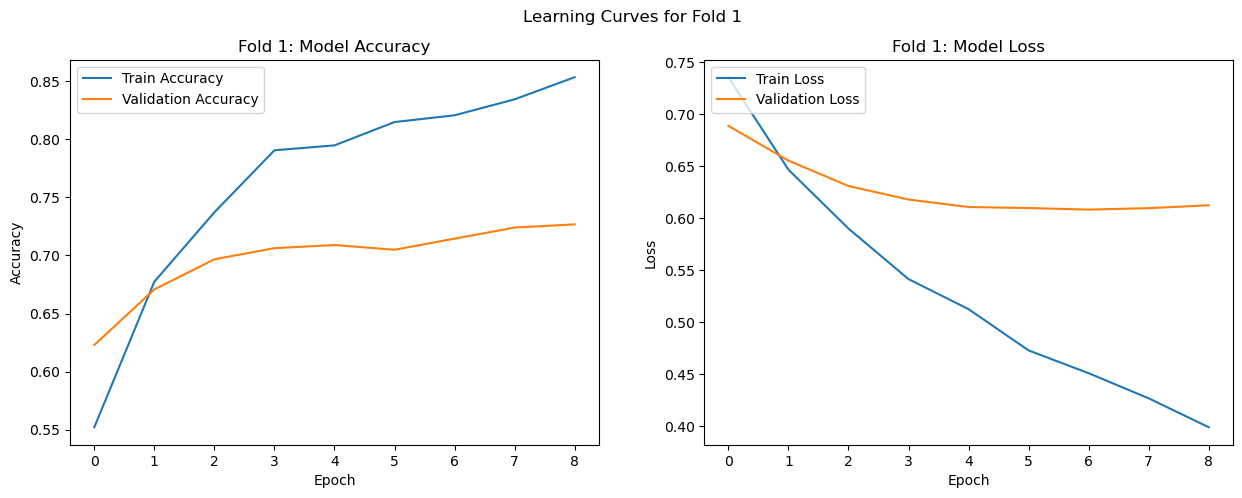

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Sequence-level Accuracy = 0.7145

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.5776    0.7181    0.6403       259
           1     0.8220    0.7125    0.7633       473

    accuracy                         0.7145       732
   macro avg     0.6998    0.7153    0.7018       732
weighted avg     0.7355    0.7145    0.7198       732



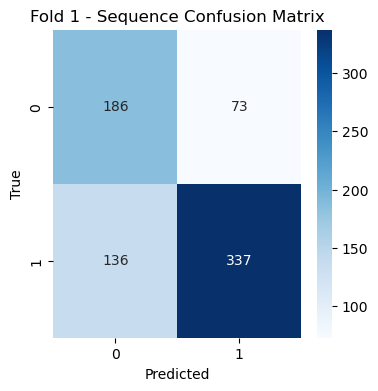

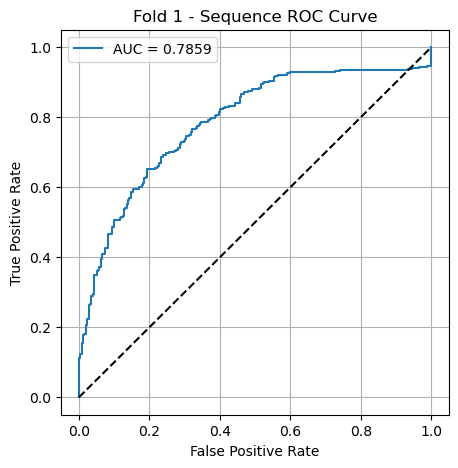

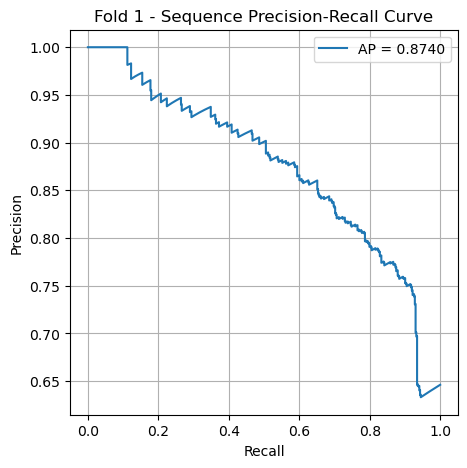


File-level Accuracy = 0.7333

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.7069    0.7321    0.7193        56
           1     0.7581    0.7344    0.7460        64

    accuracy                         0.7333       120
   macro avg     0.7325    0.7333    0.7327       120
weighted avg     0.7342    0.7333    0.7336       120



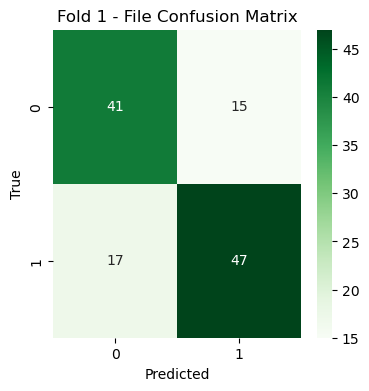

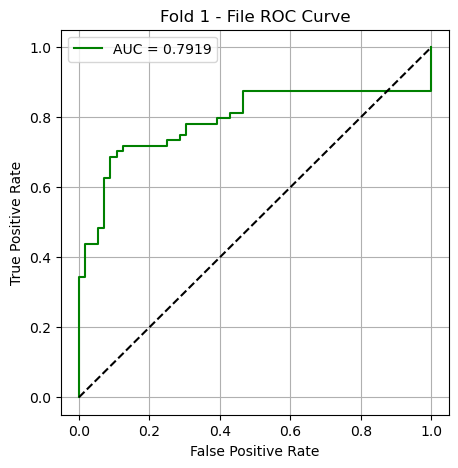

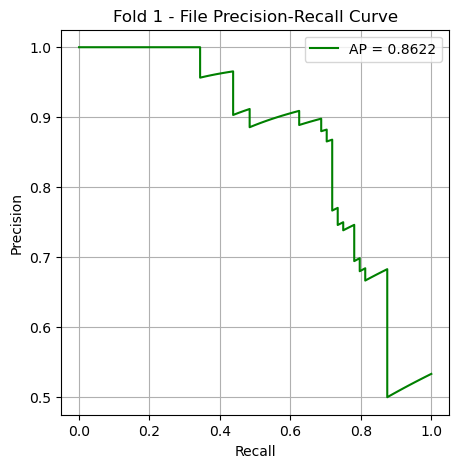


Person-level Accuracy = 0.7692

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.8333    0.7143    0.7692         7
           1     0.7143    0.8333    0.7692         6

    accuracy                         0.7692        13
   macro avg     0.7738    0.7738    0.7692        13
weighted avg     0.7784    0.7692    0.7692        13



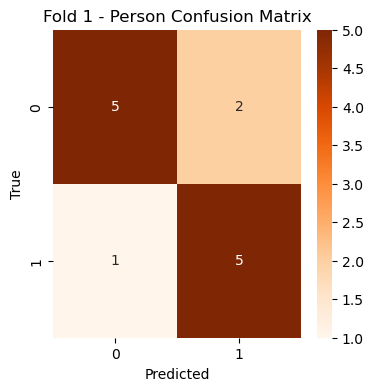

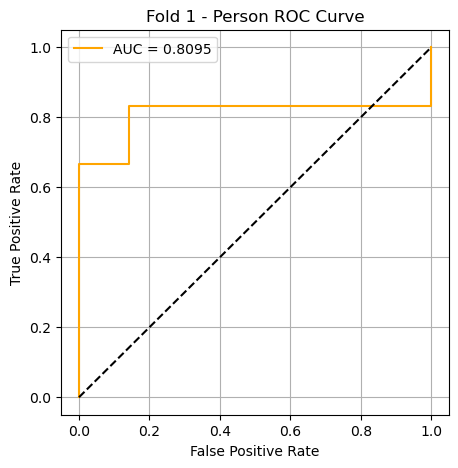

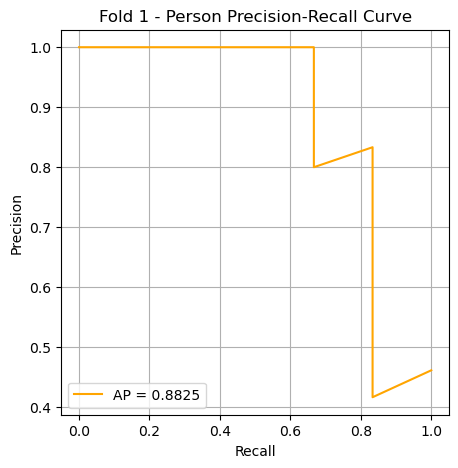


--- Fold 2 ---
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5890 - loss: 0.7096 - val_accuracy: 0.6680 - val_loss: 0.6876 - learning_rate: 1.0000e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7002 - loss: 0.6326 - val_accuracy: 0.7306 - val_loss: 0.6341 - learning_rate: 1.0000e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7262 - loss: 0.5783 - val_accuracy: 0.7497 - val_loss: 0.5974 - learning_rate: 1.0000e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7781 - loss: 0.5370 - val_accuracy: 0.7701 - val_loss: 0.5718 - learning_rate: 1.0000e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7775 - loss: 0.5146 - val_accuracy: 0.7687 - val_loss: 0.5590 - learning_rate: 1.0000e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7966 - loss: 0.4776 - val_accuracy: 0.7646 - val_loss: 0.5516 - learning_rate: 1.0000e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/s


✅ Model saved to: saved_cv_models\fold_2_model.h5


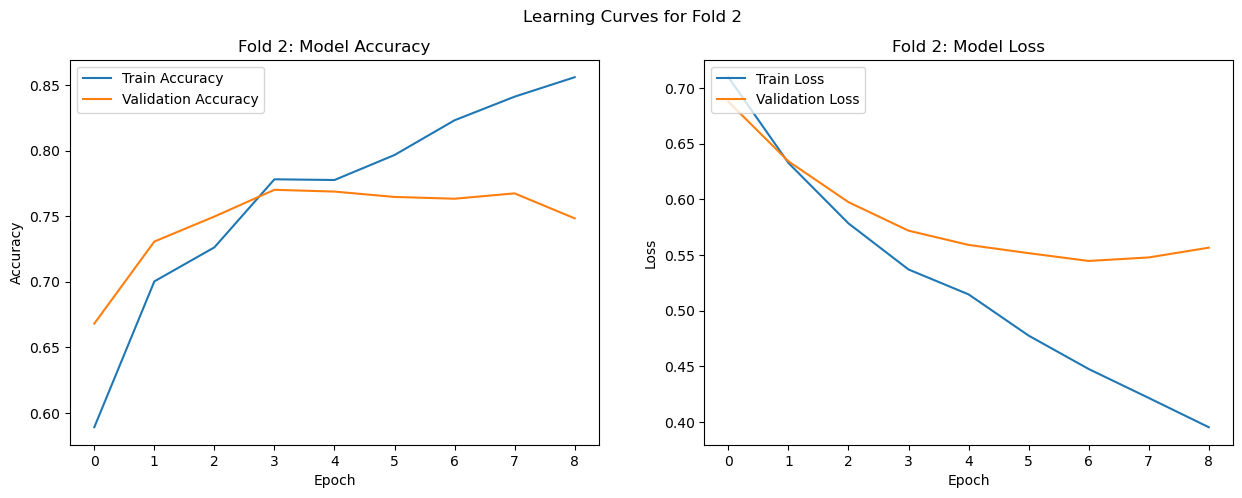

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

Sequence-level Accuracy = 0.7633

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.6644    0.7279    0.6947       272
           1     0.8307    0.7840    0.8067       463

    accuracy                         0.7633       735
   macro avg     0.7475    0.7560    0.7507       735
weighted avg     0.7691    0.7633    0.7652       735



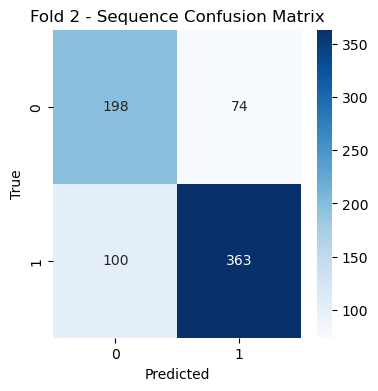

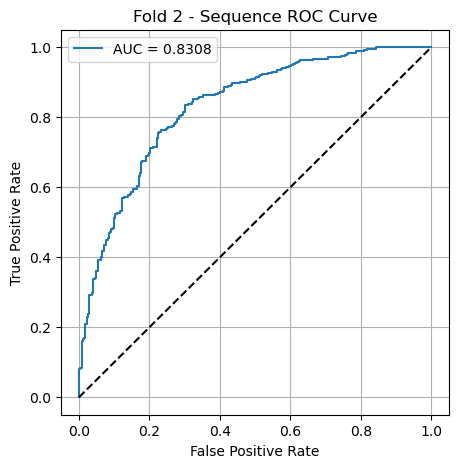

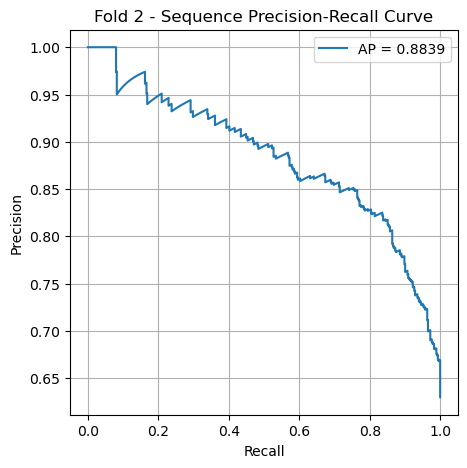


File-level Accuracy = 0.8203

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.7797    0.8214    0.8000        56
           1     0.8551    0.8194    0.8369        72

    accuracy                         0.8203       128
   macro avg     0.8174    0.8204    0.8184       128
weighted avg     0.8221    0.8203    0.8207       128



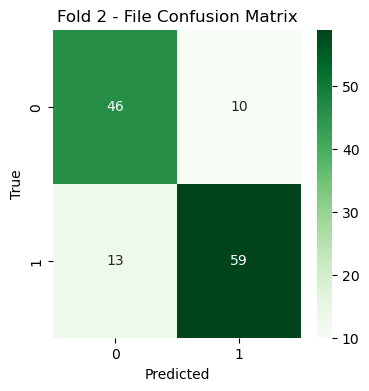

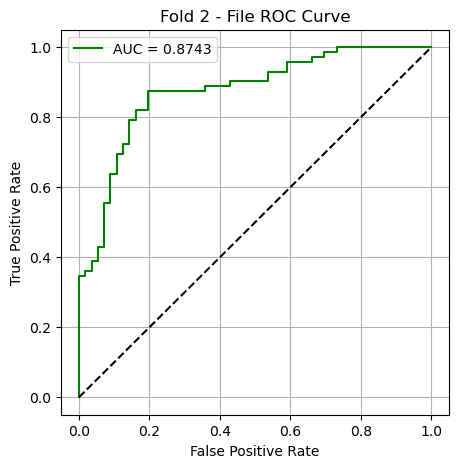

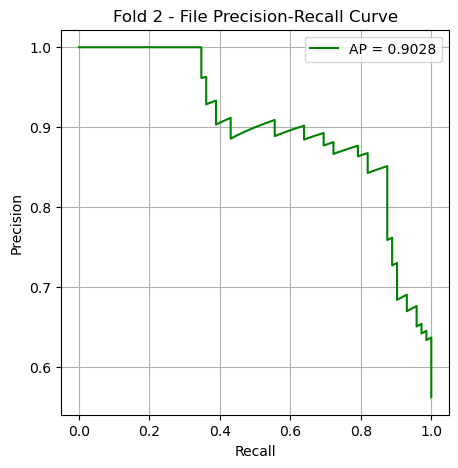


Person-level Accuracy = 0.9231

Person-level Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8571    0.9231         7
           1     0.8571    1.0000    0.9231         6

    accuracy                         0.9231        13
   macro avg     0.9286    0.9286    0.9231        13
weighted avg     0.9341    0.9231    0.9231        13



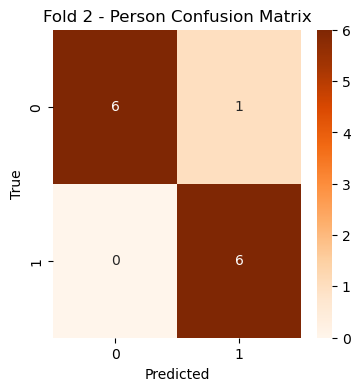

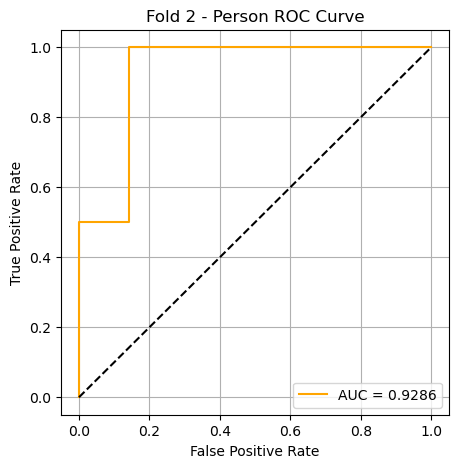

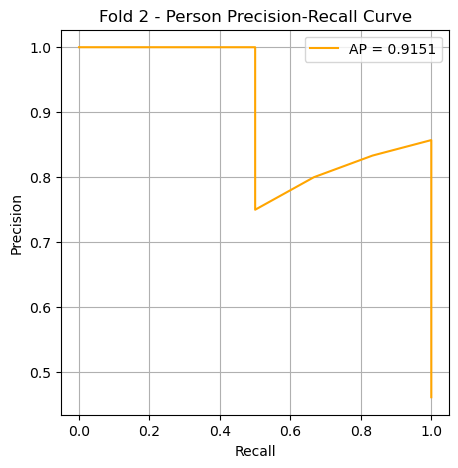


--- Fold 3 ---
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.5433 - loss: 0.7286 - val_accuracy: 0.6225 - val_loss: 0.7000 - learning_rate: 1.0000e-04
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6766 - loss: 0.6583 - val_accuracy: 0.6937 - val_loss: 0.6501 - learning_rate: 1.0000e-04
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7187 - loss: 0.6080 - val_accuracy: 0.7334 - val_loss: 0.6123 - learning_rate: 1.0000e-04
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7637 - loss: 0.5698 - val_accuracy: 0.7699 - val_loss: 0.5800 - learning_rate: 1.0000e-04
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7845 - loss: 0.5282 - val_accuracy: 0.7947 - val_loss: 0.5547 - learning_rate: 1.0000e-04
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7999 - loss: 0.5024 - val_accuracy: 0.8030 - val_loss: 0.5324 - learning_rate: 1.0000e-04
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/s


✅ Model saved to: saved_cv_models\fold_3_model.h5


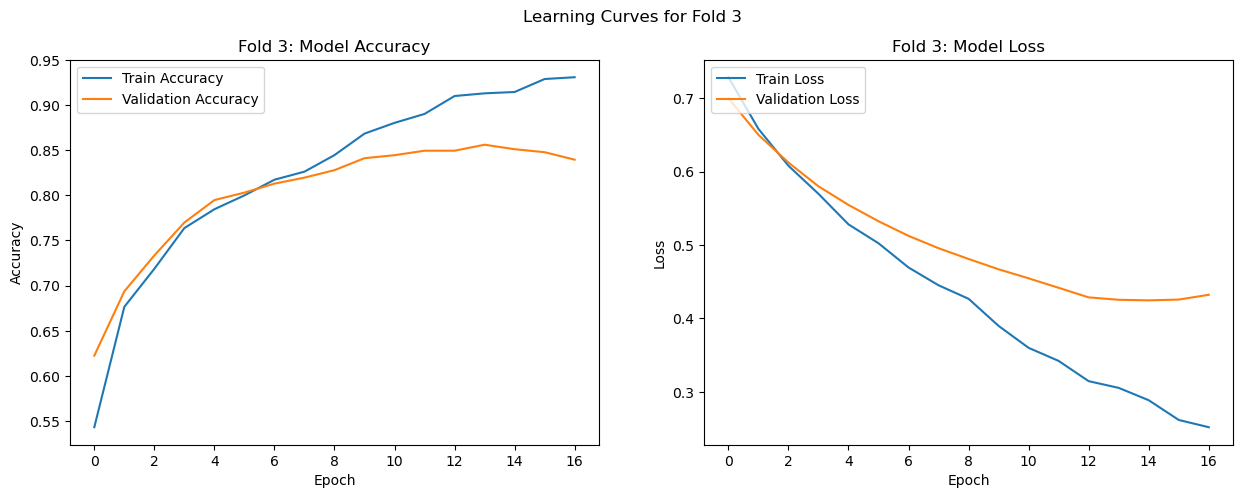

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Sequence-level Accuracy = 0.8510

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.8893    0.8084    0.8469       308
           1     0.8179    0.8953    0.8548       296

    accuracy                         0.8510       604
   macro avg     0.8536    0.8519    0.8509       604
weighted avg     0.8543    0.8510    0.8508       604



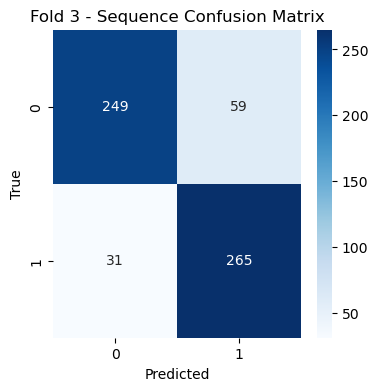

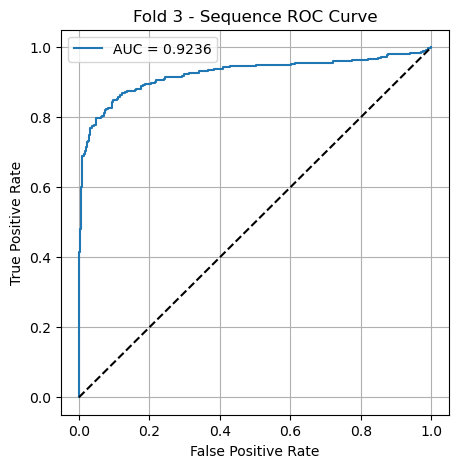

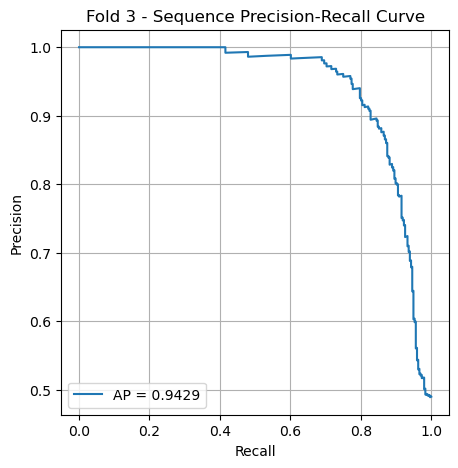


File-level Accuracy = 0.8558

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.9153    0.8438    0.8780        64
           1     0.7778    0.8750    0.8235        40

    accuracy                         0.8558       104
   macro avg     0.8465    0.8594    0.8508       104
weighted avg     0.8624    0.8558    0.8571       104



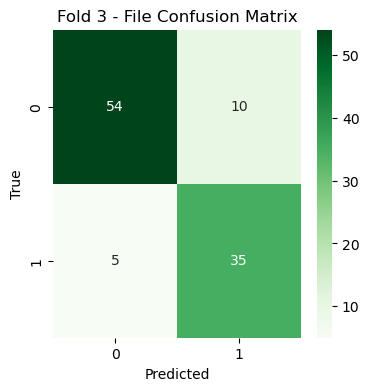

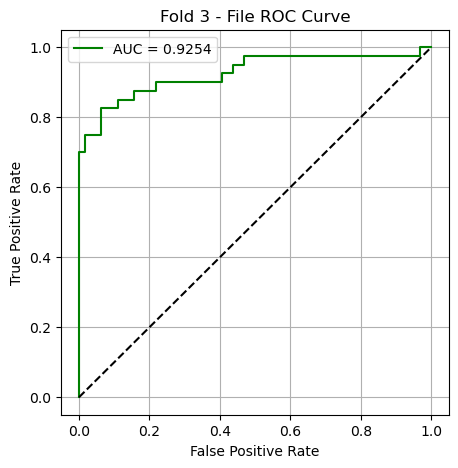

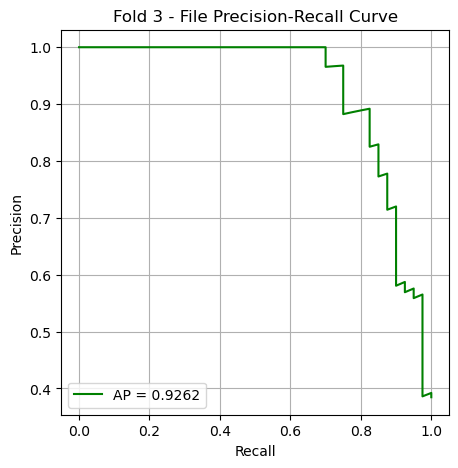


Person-level Accuracy = 0.9231

Person-level Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.8750    0.9333         8
           1     0.8333    1.0000    0.9091         5

    accuracy                         0.9231        13
   macro avg     0.9167    0.9375    0.9212        13
weighted avg     0.9359    0.9231    0.9240        13



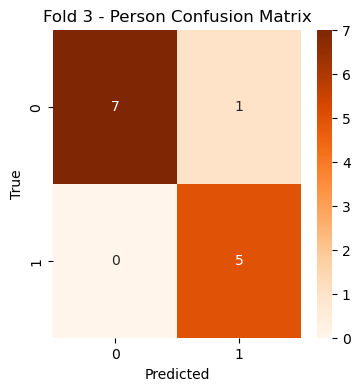

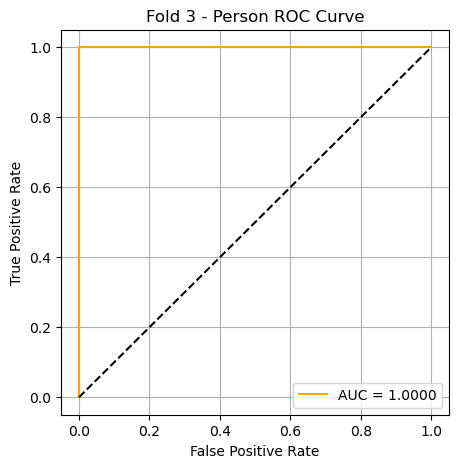

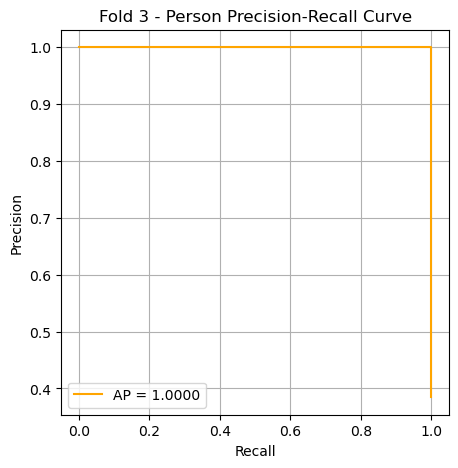


--- Fold 4 ---
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.6321 - loss: 0.6947 - val_accuracy: 0.6975 - val_loss: 0.6425 - learning_rate: 1.0000e-04
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6939 - loss: 0.6297 - val_accuracy: 0.7120 - val_loss: 0.6121 - learning_rate: 1.0000e-04
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7605 - loss: 0.5735 - val_accuracy: 0.7337 - val_loss: 0.5959 - learning_rate: 1.0000e-04
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7764 - loss: 0.5404 - val_accuracy: 0.7319 - val_loss: 0.5856 - learning_rate: 1.0000e-04
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7871 - loss: 0.5119 - val_accuracy: 0.7355 - val_loss: 0.5805 - learning_rate: 1.0000e-04
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8155 - loss: 0.4708 - val_accuracy: 0.7518 - val_loss: 0.5756 - learning_rate: 1.0000e-04
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/s


✅ Model saved to: saved_cv_models\fold_4_model.h5


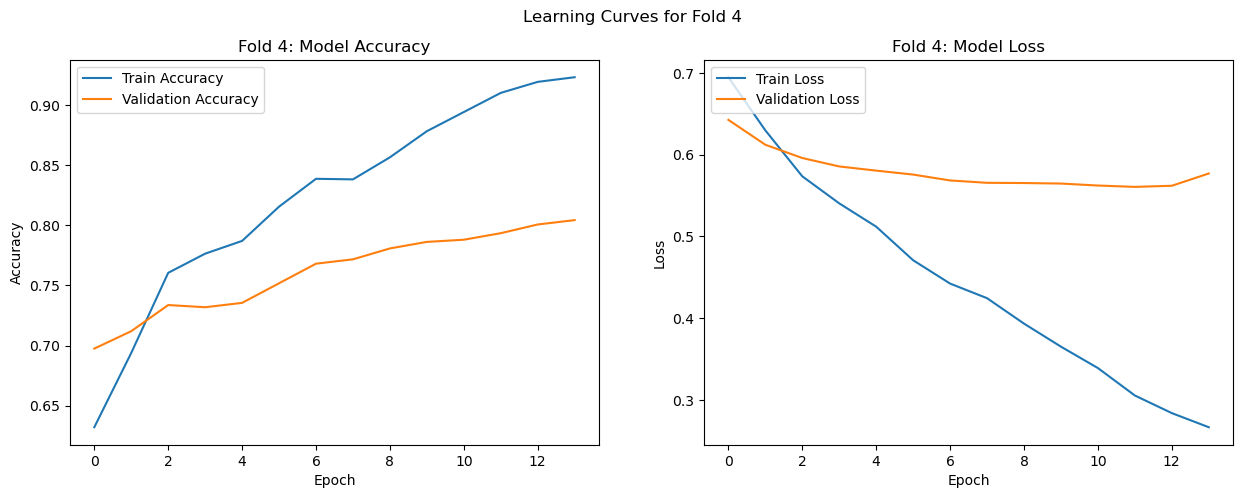

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

Sequence-level Accuracy = 0.7935

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.7692    0.7296    0.7489       233
           1     0.8097    0.8401    0.8246       319

    accuracy                         0.7935       552
   macro avg     0.7894    0.7849    0.7868       552
weighted avg     0.7926    0.7935    0.7927       552



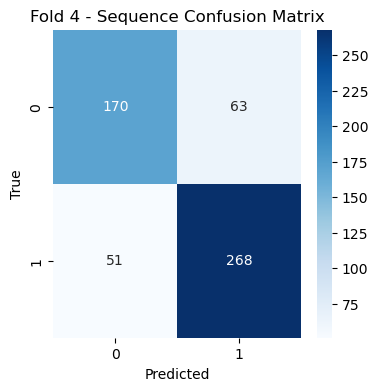

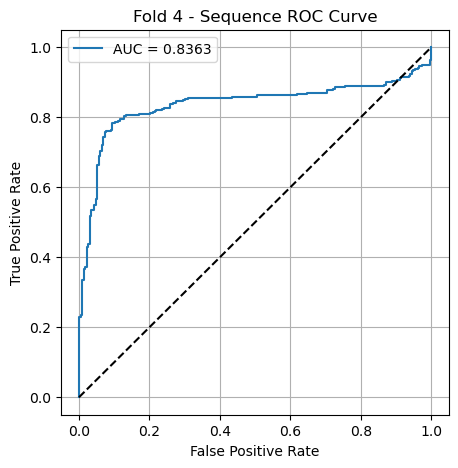

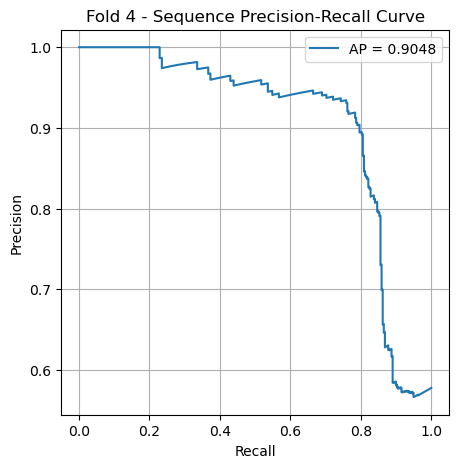


File-level Accuracy = 0.7609

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.8125    0.7500    0.7800        52
           1     0.7045    0.7750    0.7381        40

    accuracy                         0.7609        92
   macro avg     0.7585    0.7625    0.7590        92
weighted avg     0.7656    0.7609    0.7618        92



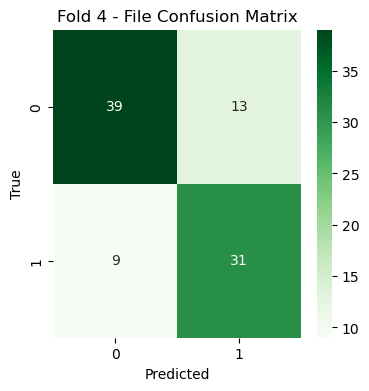

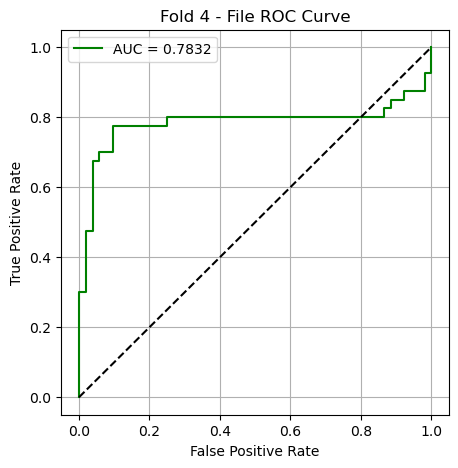

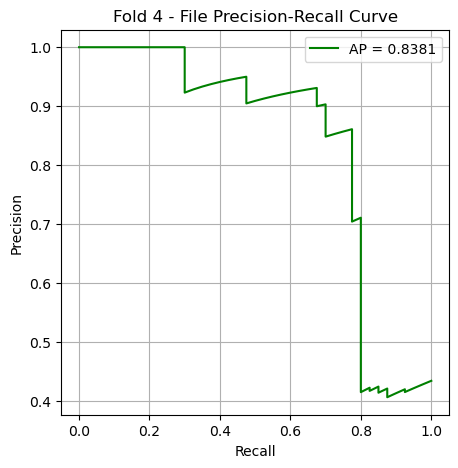


Person-level Accuracy = 0.8333

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.8571    0.8571    0.8571         7
           1     0.8000    0.8000    0.8000         5

    accuracy                         0.8333        12
   macro avg     0.8286    0.8286    0.8286        12
weighted avg     0.8333    0.8333    0.8333        12



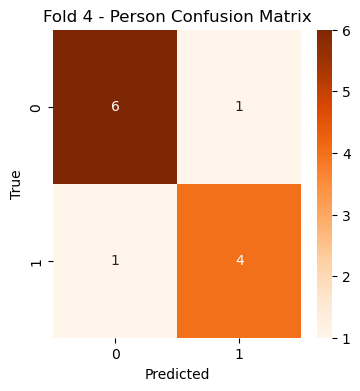

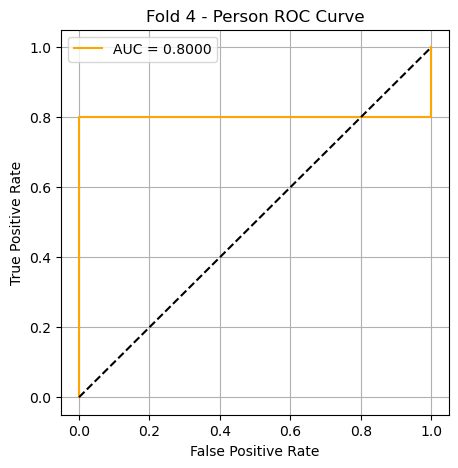

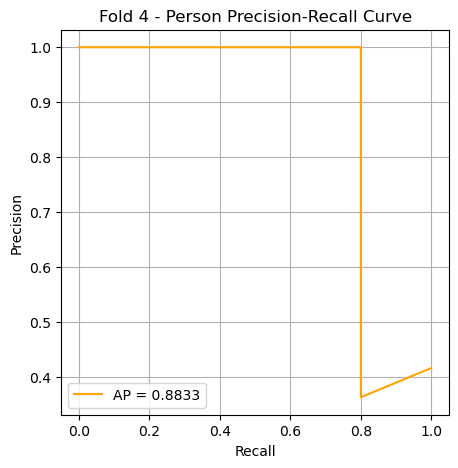


Cross-Validation Summary (Sequence-level)
Mean Accuracy: 0.7806 ± 0.0495
Mean AUC: 0.8442 ± 0.0498

Cross-Validation Summary (File-level)
Mean Accuracy: 0.7926 ± 0.0482
Mean AUC: 0.8437 ± 0.0591

Cross-Validation Summary (Person-level)
Mean Accuracy: 0.8622 ± 0.0650
Mean AUC: 0.8845 ± 0.0837

Final Comparison Table: Sequence vs File vs Person Level


,Metric,Sequence (Mean ± SD),File (Mean ± SD),Person (Mean ± SD)
0,Accuracy,0.7806 ± 0.0495,0.7926 ± 0.0482,0.8622 ± 0.0650
1,AUC,0.8442 ± 0.0498,0.8437 ± 0.0591,0.8845 ± 0.0837
2,Precision (Class 0),0.7251 ± 0.1165,0.8036 ± 0.0750,0.9226 ± 0.0778
3,Recall (Class 0),0.7460 ± 0.0363,0.7868 ± 0.0469,0.8259 ± 0.0648
4,F1 (Class 0),0.7327 ± 0.0763,0.7943 ± 0.0567,0.8707 ± 0.0655
5,Precision (Class 1),0.8200 ± 0.0076,0.7739 ± 0.0540,0.8012 ± 0.0541
6,Recall (Class 1),0.8080 ± 0.0677,0.8010 ± 0.0523,0.9083 ± 0.0924
7,F1 (Class 1),0.8124 ± 0.0331,0.7861 ± 0.0444,0.8503 ± 0.0668


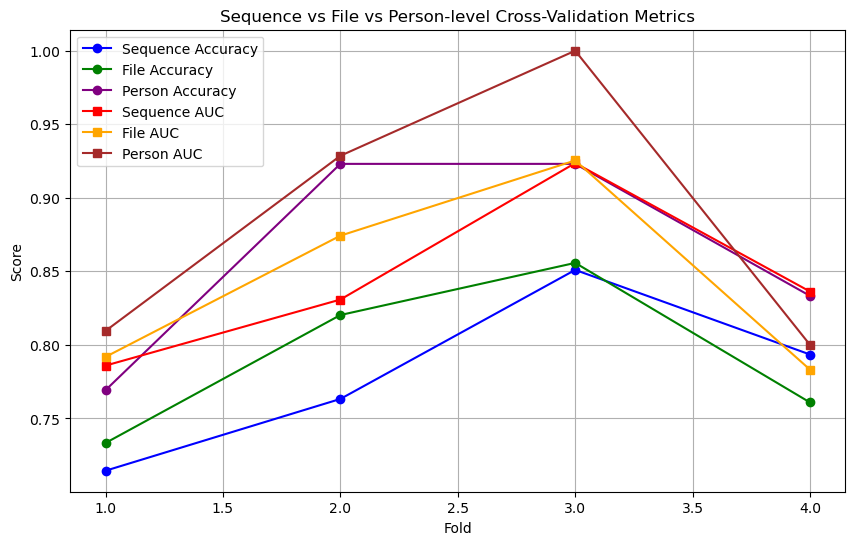

In [18]:
# =====================================
# K-FOLD CROSS-VALIDATION
# =====================================

# Map file to person
file_to_person = df_train.groupby("file_name")["Person_ID_Number"].first().to_dict()
sequence_person_ids_train = np.array([file_to_person[f] for f in sequence_file_names_train])

# Get unique persons and their corresponding labels
person_label_df = df_train.groupby("Person_ID_Number")['label'].first().reset_index()
unique_person_ids = person_label_df['Person_ID_Number'].values
person_labels = person_label_df['label'].values # <-- Labels to stratify by

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed)

# For sequence-level
fold_accuracies = []
fold_aucs = []
fold_reports = []

# For file-level
fold_file_accuracies = []
fold_file_aucs = []
fold_file_reports = []

# For person-level
fold_person_accuracies = []
fold_person_aucs = []
fold_person_reports = []

print("\nStarting 4-fold cross-validation...")

# Create directory to save models
import os
model_save_dir = "saved_cv_models"
os.makedirs(model_save_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_person_ids, person_labels), 1):
    print(f"\n--- Fold {fold} ---")
    
    train_persons = unique_person_ids[train_idx]
    val_persons = unique_person_ids[val_idx]
    
    train_mask = np.isin(sequence_person_ids_train, train_persons)
    val_mask = np.isin(sequence_person_ids_train, val_persons)
    
    X_tr = X_train_final[train_mask]
    y_tr = y_train_seq[train_mask]
    X_val = X_train_final[val_mask]
    y_val = y_train_seq[val_mask]
    file_names_val = sequence_file_names_train[val_mask]
    person_ids_val = sequence_person_ids_train[val_mask]

    model = create_bilstm_model(input_shape=(X_tr.shape[1], X_tr.shape[2]))

    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=2,  
        mode='min',
        restore_best_weights=True, 
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=2,  
        min_lr=1e-7, 
        verbose=1
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # 🆕 SAVE THE TRAINED MODEL
    model_path = os.path.join(model_save_dir, f"fold_{fold}_model.h5")
    model.save(model_path)
    print(f"\n✅ Model saved to: {model_path}")
    
    # Plot training & validation accuracy and loss for the current fold
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'Fold {fold}: Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Plot training & validation loss values
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'Fold {fold}: Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.suptitle(f'Learning Curves for Fold {fold}')
    plt.show()

    # Sequence-level Evaluation
    y_val_pred_prob = model.predict(X_val)
    y_val_pred = (y_val_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_val, y_val_pred)
    fpr, tpr, _ = roc_curve(y_val, y_val_pred_prob)
    auc_score = auc(fpr, tpr)
    
    print(f"\nSequence-level Accuracy = {acc:.4f}")
    print("\nSequence-level Classification Report:")
    print(classification_report(y_val, y_val_pred, digits=4))

    # Confusion Matrix
    cm_seq = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_seq, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Fold {fold} - Sequence Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - Sequence ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_val, y_val_pred_prob)
    ap = average_precision_score(y_val, y_val_pred_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec, prec, label=f"AP = {ap:.4f}")
    plt.title(f'Fold {fold} - Sequence Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_accuracies.append(acc)
    fold_aucs.append(auc_score)

    fold_reports.append({
        "fold": fold,
        "accuracy": acc,
        "auc": auc_score,
        "classification_report": classification_report(y_val, y_val_pred, digits=4, output_dict=True)
    })

    # File-level Evaluation
    df_val = pd.DataFrame({
        "file_name": file_names_val,
        "true_label": y_val,
        "pred_label": y_val_pred,
        "pred_prob": y_val_pred_prob.flatten()
    })

    file_prob = df_val.groupby("file_name")["pred_prob"].mean()
    file_pred = (file_prob >= 0.5).astype(int)
    file_true = df_val.groupby("file_name")["true_label"].first()

    file_acc = accuracy_score(file_true, file_pred)
    fpr_file, tpr_file, _ = roc_curve(file_true, file_prob)
    file_auc = auc(fpr_file, tpr_file)
    
    print(f"\nFile-level Accuracy = {file_acc:.4f}")
    print("\nFile-level Classification Report:")
    print(classification_report(file_true, file_pred, digits=4))

    # Confusion Matrix
    cm_file = confusion_matrix(file_true, file_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_file, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Fold {fold} - File Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr_file, tpr_file, label=f"AUC = {file_auc:.4f}", color='green')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - File ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec_file, rec_file, _ = precision_recall_curve(file_true, file_prob)
    ap_file = average_precision_score(file_true, file_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec_file, prec_file, label=f"AP = {ap_file:.4f}", color='green')
    plt.title(f'Fold {fold} - File Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_file_accuracies.append(file_acc)
    fold_file_aucs.append(file_auc)

    fold_file_reports.append({
        "fold": fold,
        "accuracy": file_acc,
        "auc": file_auc,
        "classification_report": classification_report(file_true, file_pred, digits=4, output_dict=True)
    })
    
    # Person-level Evaluation
    df_val_person = pd.DataFrame({
        "person_id": person_ids_val,
        "true_label": y_val,
        "pred_label": y_val_pred,
        "pred_prob": y_val_pred_prob.flatten()
    })

    person_prob = df_val_person.groupby("person_id")["pred_prob"].mean()
    person_pred = (person_prob >= 0.5).astype(int)
    person_true = df_val_person.groupby("person_id")["true_label"].first()

    person_acc = accuracy_score(person_true, person_pred)
    fpr_person, tpr_person, _ = roc_curve(person_true, person_prob)
    person_auc = auc(fpr_person, tpr_person)

    print(f"\nPerson-level Accuracy = {person_acc:.4f}")
    print("\nPerson-level Classification Report:")
    print(classification_report(person_true, person_pred, digits=4))

    # Confusion Matrix
    cm_person = confusion_matrix(person_true, person_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_person, annot=True, fmt='d', cmap='Oranges')
    plt.title(f'Fold {fold} - Person Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr_person, tpr_person, label=f"AUC = {person_auc:.4f}", color='orange')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - Person ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec_person, rec_person, _ = precision_recall_curve(person_true, person_prob)
    ap_person = average_precision_score(person_true, person_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec_person, prec_person, label=f"AP = {ap_person:.4f}", color='orange')
    plt.title(f'Fold {fold} - Person Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_person_accuracies.append(person_acc)
    fold_person_aucs.append(person_auc)

    fold_person_reports.append({
        "fold": fold,
        "accuracy": person_acc,
        "auc": person_auc,
        "classification_report": classification_report(person_true, person_pred, digits=4, output_dict=True)
    })

# Summary of CV results
print("\nCross-Validation Summary (Sequence-level)")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

seq_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_reports]
seq_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_reports]
seq_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_reports]

seq_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_reports]
seq_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_reports]
seq_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_reports]

print("\nCross-Validation Summary (File-level)")
print(f"Mean Accuracy: {np.mean(fold_file_accuracies):.4f} ± {np.std(fold_file_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_file_aucs):.4f} ± {np.std(fold_file_aucs):.4f}")

file_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_file_reports]
file_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_file_reports]
file_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_file_reports]

file_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_file_reports]
file_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_file_reports]
file_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_file_reports]

print("\nCross-Validation Summary (Person-level)")
print(f"Mean Accuracy: {np.mean(fold_person_accuracies):.4f} ± {np.std(fold_person_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_person_aucs):.4f} ± {np.std(fold_person_aucs):.4f}")

person_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_person_reports]
person_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_person_reports]
person_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_person_reports]

person_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_person_reports]
person_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_person_reports]
person_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_person_reports]

# Final Comparison Table
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "AUC",
               "Precision (Class 0)", "Recall (Class 0)", "F1 (Class 0)",
               "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)"],
    "Sequence (Mean ± SD)": [
        f"{np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}",
        f"{np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}",
        f"{np.mean(seq_precisions_0):.4f} ± {np.std(seq_precisions_0):.4f}",
        f"{np.mean(seq_recalls_0):.4f} ± {np.std(seq_recalls_0):.4f}",
        f"{np.mean(seq_f1s_0):.4f} ± {np.std(seq_f1s_0):.4f}",
        f"{np.mean(seq_precisions_1):.4f} ± {np.std(seq_precisions_1):.4f}",
        f"{np.mean(seq_recalls_1):.4f} ± {np.std(seq_recalls_1):.4f}",
        f"{np.mean(seq_f1s_1):.4f} ± {np.std(seq_f1s_1):.4f}"
    ],
    "File (Mean ± SD)": [
        f"{np.mean(fold_file_accuracies):.4f} ± {np.std(fold_file_accuracies):.4f}",
        f"{np.mean(fold_file_aucs):.4f} ± {np.std(fold_file_aucs):.4f}",
        f"{np.mean(file_precisions_0):.4f} ± {np.std(file_precisions_0):.4f}",
        f"{np.mean(file_recalls_0):.4f} ± {np.std(file_recalls_0):.4f}",
        f"{np.mean(file_f1s_0):.4f} ± {np.std(file_f1s_0):.4f}",
        f"{np.mean(file_precisions_1):.4f} ± {np.std(file_precisions_1):.4f}",
        f"{np.mean(file_recalls_1):.4f} ± {np.std(file_recalls_1):.4f}",
        f"{np.mean(file_f1s_1):.4f} ± {np.std(file_f1s_1):.4f}"
    ],
    "Person (Mean ± SD)": [
        f"{np.mean(fold_person_accuracies):.4f} ± {np.std(fold_person_accuracies):.4f}",
        f"{np.mean(fold_person_aucs):.4f} ± {np.std(fold_person_aucs):.4f}",
        f"{np.mean(person_precisions_0):.4f} ± {np.std(person_precisions_0):.4f}",
        f"{np.mean(person_recalls_0):.4f} ± {np.std(person_recalls_0):.4f}",
        f"{np.mean(person_f1s_0):.4f} ± {np.std(person_f1s_0):.4f}",
        f"{np.mean(person_precisions_1):.4f} ± {np.std(person_precisions_1):.4f}",
        f"{np.mean(person_recalls_1):.4f} ± {np.std(person_recalls_1):.4f}",
        f"{np.mean(person_f1s_1):.4f} ± {np.std(person_f1s_1):.4f}"
    ]
})

print("\nFinal Comparison Table: Sequence vs File vs Person Level")
display(results_table)

# Plot CV metrics
plt.figure(figsize=(10,6))
plt.plot(range(1, len(fold_accuracies)+1), fold_accuracies, marker='o', label='Sequence Accuracy', color='blue')
plt.plot(range(1, len(fold_file_accuracies)+1), fold_file_accuracies, marker='o', label='File Accuracy', color='green')
plt.plot(range(1, len(fold_person_accuracies)+1), fold_person_accuracies, marker='o', label='Person Accuracy', color='purple')
plt.plot(range(1, len(fold_aucs)+1), fold_aucs, marker='s', label='Sequence AUC', color='red')
plt.plot(range(1, len(fold_file_aucs)+1), fold_file_aucs, marker='s', label='File AUC', color='orange')
plt.plot(range(1, len(fold_person_aucs)+1), fold_person_aucs, marker='s', label='Person AUC', color='brown')
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Sequence vs File vs Person-level Cross-Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()